# CONFIG PATHS + BASIC SETUP

In [3]:
# =========================
# BLOCK 0 — ALL CONFIG (FINAL, SINGLE SOURCE OF TRUTH)
# =========================
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch

# =========================================================
# PROJECT & DEVICE
# =========================================================
PROJECT_ROOT = Path(r"E:\TDTu\TAI_LIEU\KY1-NAM5\DU_AN_CNTT")
assert PROJECT_ROOT.exists()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# =========================================================
# INPUT DATA (SINGLE FILE, NO PART)
# =========================================================
INPUT_OHLCV = PROJECT_ROOT / "src/backtest/main_data/ohlcv/ohlcv_backtest3_cut1.csv"
INPUT_MEDIA = PROJECT_ROOT / "src/backtest/main_data/media/media_backtest3_cut1.csv"

# =========================================================
# CHECKPOINTS
# =========================================================
SCALER_PATH = PROJECT_ROOT / "results/scaler/ohlcv_minmax_train.json"

FINBERT_DIR = PROJECT_ROOT / "models/finBERT/finbert_finetuned_sampler_v2"

ATT_CNN_CKPT = PROJECT_ROOT / "results/lstm_advanced/v3/att_cnn_lstm_v3.pt"
TRF_CKPT     = PROJECT_ROOT / "results/lstm_advanced/v3/transformer_v3.pt"

FUSION_CKPT  = PROJECT_ROOT / "results/fusion_rl/v2/fusion_mlp_v2.pt"
BANDIT_CKPT  = PROJECT_ROOT / "results/rl_agent/bandit_fusion/linucb_full_fusion_train_v1.npz"

# =========================================================
# TIME SERIES
# =========================================================
LOOKBACK = 60          # sliding window length (hours)
STEP_SIZE = 1          # slide 1 hour / step

FEATURE_COLS = [
    "open", "high", "low", "close", "volume", "sma14", "rsi14"
]

# =========================================================
# MODEL CONFIG — ATT-CNN-LSTM v3
# =========================================================
ATT_CFG = {
    "input_dim": len(FEATURE_COLS),  # 7
    "hidden_dim": 256,
    "num_layers": 2,
    "dropout": 0.3,
    "embed_dim": 768,                # OUTPUT (observed)
}

# =========================================================
# MODEL CONFIG — TRANSFORMER v3
# =========================================================
TRF_CFG = {
    "input_dim": len(FEATURE_COLS),  # 7
    "embed_dim": 256,
    "num_heads": 4,
    "num_layers": 2,
    "dropout": 0.3,
    "out_dim": 512,                  # OUTPUT (observed)
}

# =========================================================
# MODEL CONFIG — FUSION MLP
# =========================================================
FUSION_CFG = {
    "input_dim": 768 + 512 + 3,      # Att + Trf + FinBERT
    "hidden_dims": [1024, 512],
    "output_dim": 256,
    "dropout": 0.2,
    "layer_norm": True,
}

# =========================================================
# BANDIT CONFIG (BEST FROM BACKTEST)
# =========================================================
BANDIT_CFG = {
    "alpha": 0.22,
    "gamma": 0.999,
    "cooldown": 10,
    "min_adv": 0.002,
    "eps_abs": 0.0003,
    "eps_pct": 0.0,
    "flat_adv": 0.0,
    "reset_prior": 1,
    "use_trend": 0,
    "sma_fast": 30,
    "sma_slow": 120,
    "forbid_to_flat": 1,
    "zero_to_flat": 1,
    "flip_to_flat": 1,
}

ACTION_MAP = {0: "FLAT", 1: "LONG", 2: "SHORT"}
MAX_HOLD = 24  # hours

print("BLOCK 0 (ALL CONFIG FINAL) loaded")


DEVICE: cuda
BLOCK 0 (ALL CONFIG FINAL) loaded


# LOAD & PROCESS DATA

In [4]:
# =========================
# BLOCK 1 — LOAD & PREPROCESS DATA
# =========================
import json

# =========================================================
# 1) LOAD OHLCV
# =========================================================
ohlcv = pd.read_csv(INPUT_OHLCV)

# ---- timestamp ----
ohlcv["timestamp"] = pd.to_datetime(ohlcv["timestamp"])
ohlcv = ohlcv.sort_values("timestamp").reset_index(drop=True)

# ---- sanity ----
required_cols = {"timestamp", "open", "high", "low", "close", "volume"}
missing = required_cols - set(ohlcv.columns)
assert not missing, f"Missing OHLCV columns: {missing}"

print(f"OHLCV loaded: {len(ohlcv)} rows")
print("OHLCV time range:", ohlcv["timestamp"].min(), "→", ohlcv["timestamp"].max())

# =========================================================
# 2) LOAD MEDIA
# =========================================================
media = pd.read_csv(INPUT_MEDIA)

media["timestamp"] = pd.to_datetime(media["timestamp"])
media = media.sort_values("timestamp").reset_index(drop=True)

assert "title" in media.columns, "media file must have column: title"

print(f"Media loaded: {len(media)} rows")
print("Media time range:", media["timestamp"].min(), "→", media["timestamp"].max())

# =========================================================
# 3) TECHNICAL INDICATORS (MATCH TRAIN)
# =========================================================
def compute_sma(series: pd.Series, window: int = 14):
    return series.rolling(window, min_periods=1).mean()

def compute_rsi(series: pd.Series, window: int = 14):
    delta = series.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)

    avg_gain = gain.rolling(window, min_periods=1).mean()
    avg_loss = loss.rolling(window, min_periods=1).mean()

    rs = avg_gain / (avg_loss + 1e-12)
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi.clip(0.0, 100.0)

ohlcv["sma14"] = compute_sma(ohlcv["close"], 14)
ohlcv["rsi14"] = compute_rsi(ohlcv["close"], 14)

# =========================================================
# 4) FINAL FEATURE CHECK
# =========================================================
assert all(col in ohlcv.columns for col in FEATURE_COLS)

print("Feature columns ready:", FEATURE_COLS)

# =========================================================
# 5) SLIDING WINDOW SANITY
# =========================================================
if len(ohlcv) < LOOKBACK:
    raise ValueError(
        f"Not enough data for sliding window: "
        f"need >= {LOOKBACK}, got {len(ohlcv)}"
    )

print(
    f"Sliding window ready: "
    f"{len(ohlcv) - LOOKBACK + 1} decision points possible"
)

print("BLOCK 1 loaded")


OHLCV loaded: 463 rows
OHLCV time range: 2025-09-11 00:00:00 → 2025-09-30 06:00:00
Media loaded: 150 rows
Media time range: 2025-09-11 00:00:00 → 2025-09-25 00:00:00
Feature columns ready: ['open', 'high', 'low', 'close', 'volume', 'sma14', 'rsi14']
Sliding window ready: 404 decision points possible
BLOCK 1 loaded


# SCALER + SLIDING WINDOW BUILDER

In [5]:
# =========================
# BLOCK 2 — SCALER + SLIDING WINDOW BUILDER
# =========================
import json

# =========================================================
# 1) LOAD SCALER (TRAINED)
# =========================================================
with open(SCALER_PATH, "r", encoding="utf-8") as f:
    scaler_cfg = json.load(f)

assert scaler_cfg["scaler_type"] == "minmax"
assert scaler_cfg["features"] == FEATURE_COLS[:5]  # open,high,low,close,volume

mins = np.array(scaler_cfg["mins"], dtype=np.float32)
maxs = np.array(scaler_cfg["maxs"], dtype=np.float32)

print("Scaler loaded")
print("Scaler features:", scaler_cfg["features"])

# =========================================================
# 2) APPLY SCALER (PRICE FEATURES ONLY)
# =========================================================
def minmax_scale(x, mins, maxs):
    return (x - mins) / (maxs - mins + 1e-12)

ohlcv_scaled = ohlcv.copy()

price_feats = ["open", "high", "low", "close", "volume"]
ohlcv_scaled[price_feats] = minmax_scale(
    ohlcv_scaled[price_feats].values.astype(np.float32),
    mins,
    maxs,
)

# NOTE:
# sma14, rsi14 giữ nguyên scale như lúc train
# (đã verify ở các bước trước)

print("Scaling applied to price features")

# =========================================================
# 3) BUILD SLIDING WINDOWS (INDEX-BASED)
# =========================================================
def build_sliding_windows(df, feature_cols, lookback):
    """
    Returns:
        X_windows: np.ndarray [N, lookback, n_features]
        timestamps: list[pd.Timestamp] — decision time
    """
    X = df[feature_cols].values.astype(np.float32)
    ts = df["timestamp"].values

    X_windows = []
    decision_ts = []

    for i in range(lookback - 1, len(df)):
        window = X[i - lookback + 1 : i + 1]
        X_windows.append(window)
        decision_ts.append(ts[i])

    return np.stack(X_windows), decision_ts


X_windows, decision_timestamps = build_sliding_windows(
    ohlcv_scaled,
    FEATURE_COLS,
    LOOKBACK,
)

print("Sliding windows built")
print("X_windows shape:", X_windows.shape)   # [N, 60, 7]
print("Decision points:", len(decision_timestamps))

# =========================================================
# 4) SANITY CHECK
# =========================================================
assert X_windows.shape[1] == LOOKBACK
assert X_windows.shape[2] == len(FEATURE_COLS)

print("BLOCK 2 loaded")


Scaler loaded
Scaler features: ['open', 'high', 'low', 'close', 'volume']
Scaling applied to price features
Sliding windows built
X_windows shape: (404, 60, 7)
Decision points: 404
BLOCK 2 loaded


# LOAD ALL MODELS

In [6]:
# =========================
# BLOCK 3 — LOAD ALL MODELS
# =========================
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from src.lstm_advanced.train.train_att_cnn_lstm_v3 import AttCNNLSTM_v3
from src.lstm_advanced.train.train_transformer_v3 import TimeSeriesTransformerV3
from src.fusion_rl.v2.train_fusion_mlp_v2 import FusionMLP


# =========================================================
# HELPER: ROBUST CHECKPOINT LOADER
# =========================================================
def load_ckpt(model, ckpt_path, device):
    state = torch.load(ckpt_path, map_location=device)
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    model.load_state_dict(state, strict=True)
    return model


# =========================================================
# 1) FINBERT
# =========================================================
tokenizer = AutoTokenizer.from_pretrained(FINBERT_DIR)
finbert = AutoModelForSequenceClassification.from_pretrained(FINBERT_DIR)
finbert.to(DEVICE).eval()
print("FinBERT loaded")


# =========================================================
# 2) ATT-CNN-LSTM v3
# =========================================================
att_model = AttCNNLSTM_v3(
    input_dim=ATT_CFG["input_dim"],
    hidden_dim=ATT_CFG["hidden_dim"],
    num_layers=ATT_CFG["num_layers"],
    dropout=ATT_CFG["dropout"],
)

att_model = load_ckpt(att_model, ATT_CNN_CKPT, DEVICE)
att_model.to(DEVICE).eval()
print("Att-CNN-LSTM v3 loaded")


# =========================================================
# 3) TRANSFORMER v3
# =========================================================
trf_model = TimeSeriesTransformerV3(
    input_dim=TRF_CFG["input_dim"],
    embed_dim=TRF_CFG["embed_dim"],
    num_heads=TRF_CFG["num_heads"],
    num_layers=TRF_CFG["num_layers"],
    dropout=TRF_CFG["dropout"],
)

trf_model = load_ckpt(trf_model, TRF_CKPT, DEVICE)
trf_model.to(DEVICE).eval()
print("Transformer v3 loaded")


# =========================================================
# 4) FUSION MLP
# =========================================================
fusion_model = FusionMLP(
    input_dim=FUSION_CFG["input_dim"],
    hidden_dims=FUSION_CFG["hidden_dims"],
    output_dim=FUSION_CFG["output_dim"],
    dropout=FUSION_CFG["dropout"],
    layer_norm=FUSION_CFG["layer_norm"],
)

fusion_model = load_ckpt(fusion_model, FUSION_CKPT, DEVICE)
fusion_model.to(DEVICE).eval()
print("FusionMLP loaded")


print("BLOCK 3 loaded")


e:\TDTu\TAI_LIEU\KY1-NAM5\DU_AN_CNTT\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FinBERT loaded
Att-CNN-LSTM v3 loaded
Transformer v3 loaded
FusionMLP loaded
BLOCK 3 loaded


# FINBERT SLIDING AGGREGATION (MEDIA → LOGITS PER HOUR)

In [7]:
# =========================
# BLOCK 4 — FINBERT SLIDING AGGREGATION
# =========================
from typing import List

# =========================================================
# 1) HELPER: RUN FINBERT ON LIST OF TEXTS
# =========================================================
@torch.no_grad()
def finbert_logits(texts: List[str]) -> torch.Tensor:
    """
    texts: list[str]
    return: torch.Tensor shape (N, 3)
    """
    if len(texts) == 0:
        return torch.zeros((0, 3), device=DEVICE)

    enc = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt",
    ).to(DEVICE)

    out = finbert(**enc)
    return out.logits


# =========================================================
# 2) AGGREGATE LOGITS FOR EACH DECISION TIME
# =========================================================
finbert_per_step = []

for t in decision_timestamps:
    # lấy toàn bộ news trước hoặc đúng thời điểm t
    mask = media["timestamp"] <= pd.Timestamp(t)
    titles = media.loc[mask, "title"].tolist()

    logits = finbert_logits(titles)

    if logits.shape[0] == 0:
        agg = torch.zeros((1, 3), device=DEVICE)
    else:
        # mean aggregation (MATCH TRAIN)
        agg = logits.mean(dim=0, keepdim=True)

    finbert_per_step.append(agg.cpu())

finbert_per_step = torch.cat(finbert_per_step, dim=0)

print("FinBERT per-step logits built")
print("FinBERT logits shape:", finbert_per_step.shape)  # (N, 3)

# =========================================================
# 3) SANITY CHECK
# =========================================================
assert finbert_per_step.shape[0] == len(decision_timestamps)
assert finbert_per_step.shape[1] == 3

print("BLOCK 4 loaded")


FinBERT per-step logits built
FinBERT logits shape: torch.Size([404, 3])
BLOCK 4 loaded


# TIME-SERIES EMBEDDINGS (ATT-CNN + TRANSFORMER, sliding window)

In [8]:
# =========================
# BLOCK 5 — TS EMBEDDINGS (ATT + TRF) FOR ALL WINDOWS
# =========================
from math import ceil

@torch.no_grad()
def batch_embed_ts(X_windows: np.ndarray, batch_size: int = 256):
    """
    X_windows: np.ndarray (N, 60, 7)
    return:
      att_emb_all: torch.Tensor (N, 768)
      trf_emb_all: torch.Tensor (N, 512)
    """
    N = X_windows.shape[0]
    att_out = []
    trf_out = []

    n_batches = ceil(N / batch_size)

    for bi in range(n_batches):
        s = bi * batch_size
        e = min((bi + 1) * batch_size, N)

        xb = torch.tensor(X_windows[s:e], dtype=torch.float32, device=DEVICE)

        # Att-CNN forward → returns tuple (pred, emb)
        att_pred, att_emb = att_model(xb)

        # Transformer forward → returns tuple (pred, emb)
        trf_pred, trf_emb = trf_model(xb)

        att_out.append(att_emb.detach().cpu())
        trf_out.append(trf_emb.detach().cpu())

    att_emb_all = torch.cat(att_out, dim=0)
    trf_emb_all = torch.cat(trf_out, dim=0)
    return att_emb_all, trf_emb_all


att_emb_all, trf_emb_all = batch_embed_ts(X_windows, batch_size=256)

print("TS embeddings built")
print("Att emb shape:", att_emb_all.shape)  # (N, 768)
print("Trf emb shape:", trf_emb_all.shape)  # (N, 512)

# =========================================================
# SANITY
# =========================================================
assert att_emb_all.shape[0] == X_windows.shape[0]
assert trf_emb_all.shape[0] == X_windows.shape[0]

assert att_emb_all.shape[1] == ATT_CFG["embed_dim"]
assert trf_emb_all.shape[1] == TRF_CFG["out_dim"]

print("BLOCK 5 loaded")


TS embeddings built
Att emb shape: torch.Size([404, 768])
Trf emb shape: torch.Size([404, 512])
BLOCK 5 loaded


# FUSION EMBEDDING (concat + FusionMLP → z(256))

In [9]:
# =========================
# BLOCK 6 — FUSION EMBEDDINGS
# =========================

@torch.no_grad()
def build_fusion_embeddings(
    att_emb: torch.Tensor,
    trf_emb: torch.Tensor,
    finbert_emb: torch.Tensor,
    batch_size: int = 256,
):
    """
    Inputs:
      att_emb      : (N, 768)
      trf_emb      : (N, 512)
      finbert_emb  : (N, 3)
    Returns:
      z_all        : (N, 256)
    """
    N = att_emb.shape[0]
    z_out = []

    for s in range(0, N, batch_size):
        e = min(s + batch_size, N)

        x = torch.cat(
            [
                att_emb[s:e].to(DEVICE),
                trf_emb[s:e].to(DEVICE),
                finbert_emb[s:e].to(DEVICE),
            ],
            dim=1,
        )  # (B, 1283)

        recon, z = fusion_model(x)
        z_out.append(z.detach().cpu())

    return torch.cat(z_out, dim=0)


z_all = build_fusion_embeddings(
    att_emb_all,
    trf_emb_all,
    finbert_per_step,
    batch_size=256,
)

print("Fusion embeddings built")
print("Fusion z shape:", z_all.shape)  # (N, 256)

# =========================================================
# SANITY
# =========================================================
assert z_all.shape[0] == len(decision_timestamps)
assert z_all.shape[1] == FUSION_CFG["output_dim"]

print("BLOCK 6 loaded")


Fusion embeddings built
Fusion z shape: torch.Size([404, 256])
BLOCK 6 loaded


# BANDIT CONTEXT + ACTION (SLIDING 1H, LOG & SAVE)

In [12]:
import numpy as np
import pandas as pd
from datetime import datetime

# =========================================================
# 1) LOAD FULL LinUCB CHECKPOINT
# =========================================================
bandit_ckpt = np.load(BANDIT_CKPT)

A = bandit_ckpt["A"].astype(np.float64)   # (n_actions, d, d)
b = bandit_ckpt["b"].astype(np.float64)   # (n_actions, d)

n_actions, d_ckpt, _ = A.shape
assert d_ckpt == 260

print(f"Bandit FULL LinUCB loaded | n_actions={n_actions}, d={d_ckpt}")

theta = np.zeros_like(b)
for a in range(n_actions):
    theta[a] = np.linalg.solve(A[a], b[a])

ACTION_MAP = {0: "FLAT", 1: "LONG", 2: "SHORT"}


# =========================================================
# 2) EXTRA FEATURES (MATCH TRAIN)
# =========================================================
def compute_extra_features(df, idx):
    eps = 1e-12

    open_t = float(df.loc[idx, "open"])
    close_t = float(df.loc[idx, "close"])

    mom1 = np.log(np.maximum(close_t, eps) / np.maximum(open_t, eps))
    mom1 = np.clip(mom1, -0.05, 0.05)

    sma14 = float(df.loc[idx, "sma14"])
    sma_rel = (close_t - sma14) / np.maximum(abs(close_t), eps)
    sma_rel = np.clip(sma_rel, -0.2, 0.2)

    rsi_norm = float(df.loc[idx, "rsi14"]) / 100.0
    rsi_norm = np.clip(rsi_norm, 0.0, 1.0)

    return np.array([1.0, mom1, sma_rel, rsi_norm], dtype=np.float32)


# =========================================================
# 3) SCORE FUNCTION — FULL LinUCB
# =========================================================
def bandit_scores_full(x, theta, A, alpha):
    x = x.astype(np.float64)
    scores = np.zeros(theta.shape[0], dtype=np.float64)

    for a in range(theta.shape[0]):
        mean = theta[a] @ x
        bonus = alpha * np.sqrt(x @ np.linalg.solve(A[a], x))
        scores[a] = mean + bonus

    scores[0] = 0.0  # FLAT baseline
    return scores


# =========================================================
# 4) RISK LAYER — 3 GATE (BẢN GỐC)
# =========================================================
def risk_layer_3_gate(
    *,
    best,
    cur_action,
    scores,
    adv,
    min_adv,
    neutral_band,
):
    """
    Gate 1: Advantage gate
    Gate 2: Neutral band (LONG ≈ SHORT)
    Gate 3: Flip gate (LONG <-> SHORT phải qua FLAT)
    """

    # -------- Gate 1: Advantage --------
    if adv <= min_adv:
        return 0  # FLAT

    # -------- Gate 2: Neutral band --------
    if abs(scores[1] - scores[2]) < neutral_band:
        return 0  # FLAT

    # -------- Gate 3: Flip protection --------
    if cur_action != 0 and best != cur_action:
        return 0  # ép về FLAT trước

    return best


# =========================================================
# 5) SLIDING WINDOW — ACTION PER HOUR
# =========================================================
results = []
cur_action = 0

for i, ts in enumerate(decision_timestamps):

    ohlcv_idx = LOOKBACK - 1 + i

    extra = compute_extra_features(ohlcv, ohlcv_idx)
    ctx = np.concatenate([z_all[i].numpy(), extra], axis=0)
    assert ctx.shape[0] == d_ckpt

    scores = bandit_scores_full(
        ctx,
        theta,
        A,
        BANDIT_CFG["alpha"],
    )

    best = int(np.argmax(scores))
    adv = float(scores[best] - scores[0])

    # ===== APPLY 3-GATE RISK LAYER =====
    action = risk_layer_3_gate(
        best=best,
        cur_action=cur_action,
        scores=scores,
        adv=adv,
        min_adv=BANDIT_CFG["min_adv"],
        neutral_band=0.001,
    )

    cur_action = action

    results.append(
        {
            "timestamp": pd.Timestamp(ts),
            "action": ACTION_MAP[action],
            "best_raw": ACTION_MAP[best],
            "score_flat": float(scores[0]),
            "score_long": float(scores[1]),
            "score_short": float(scores[2]),
            "advantage": adv,
        }
    )


# =========================================================
# 6) SAVE LOG
# =========================================================
df_out = pd.DataFrame(results)

out_dir = "results_demo/sliding_demo"
run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"{out_dir}/bandit_inference_sliding_3GATE_{run_tag}.csv"

df_out.to_csv(out_path, index=False)
print(f"Inference results saved → {out_path}")

print("BLOCK 7 (RISK LAYER 3 GATE) loaded ")


Bandit FULL LinUCB loaded | n_actions=3, d=260
Inference results saved → results_demo/sliding_demo/bandit_inference_sliding_3GATE_20251226_220557.csv
BLOCK 7 (RISK LAYER 3 GATE) loaded 


# PLOT PRICE VS ACCOUNT BALANCE

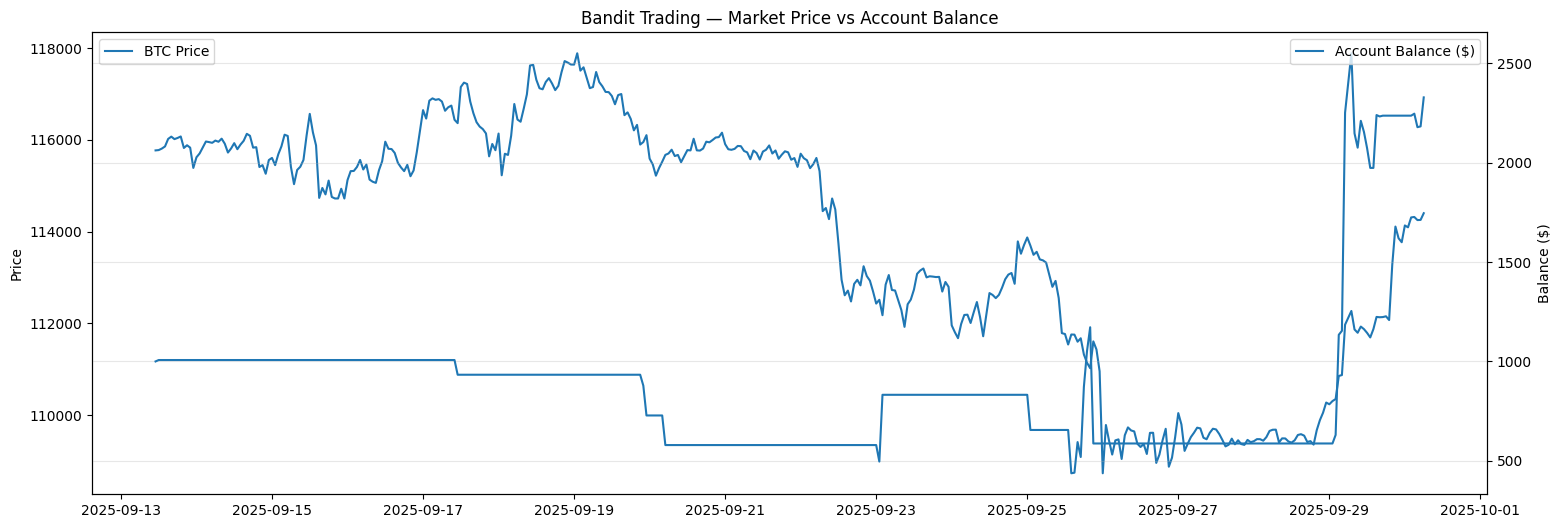

Plot saved → results_demo/sliding_demo/price_balance_plot_20251226_220600.png

========== TRADE SUMMARY ==========
Initial Balance : $1,000.00
Final Balance   : $2,329.00
Total PnL       : $1,329.00
ROI             : 132.90%
-----------------------------------
LONG  count     : 23
SHORT count     : 13
FLAT  count     : 368


In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1) LOAD DATA
# =========================================================
df = pd.read_csv(out_path)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

price_df = ohlcv[["timestamp", "close"]].copy()
price_df["timestamp"] = pd.to_datetime(price_df["timestamp"])

df = df.merge(price_df, on="timestamp", how="left")

# =========================================================
# 2) MAP ACTION → POSITION
# =========================================================
ACTION_TO_POS = {
    "FLAT": 0,
    "LONG": 1,
    "SHORT": -1,
}

df["pos"] = df["action"].map(ACTION_TO_POS).fillna(0).astype(int)

# =========================================================
# 3) SIMULATE BALANCE
# =========================================================
INIT_BALANCE = 1000.0

balance = INIT_BALANCE
balances = [balance]
pnls = [0.0]

for i in range(1, len(df)):
    price_prev = df.loc[i - 1, "close"]
    price_now = df.loc[i, "close"]
    pos_prev = df.loc[i - 1, "pos"]

    pnl = pos_prev * (price_now - price_prev)
    balance += pnl

    pnls.append(pnl)
    balances.append(balance)

df["pnl"] = pnls
df["balance"] = balances

# =========================================================
# 4) PLOT
# =========================================================
out_dir = "results_demo/sliding_demo"
os.makedirs(out_dir, exist_ok=True)

fig, ax1 = plt.subplots(figsize=(18, 6))

# ---- PRICE ----
ax1.plot(
    df["timestamp"],
    df["close"],
    label="BTC Price",
)
ax1.set_ylabel("Price")
ax1.legend(loc="upper left")

# ---- BALANCE ----
ax2 = ax1.twinx()
ax2.plot(
    df["timestamp"],
    df["balance"],
    label="Account Balance ($)",
)
ax2.set_ylabel("Balance ($)")
ax2.legend(loc="upper right")

plt.title("Bandit Trading — Market Price vs Account Balance")
plt.grid(alpha=0.3)

# ---- SAVE FIG ----
run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
fig_path = f"{out_dir}/price_balance_plot_{run_tag}.png"

plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Plot saved → {fig_path}")

# =========================================================
# 5) PRINT PnL & ROI
# =========================================================
final_balance = df["balance"].iloc[-1]
total_pnl = final_balance - INIT_BALANCE
roi_pct = total_pnl / INIT_BALANCE * 100

n_long = (df["action"] == "LONG").sum()
n_short = (df["action"] == "SHORT").sum()
n_flat = (df["action"] == "FLAT").sum()

print("\n========== TRADE SUMMARY ==========")
print(f"Initial Balance : ${INIT_BALANCE:,.2f}")
print(f"Final Balance   : ${final_balance:,.2f}")
print(f"Total PnL       : ${total_pnl:,.2f}")
print(f"ROI             : {roi_pct:.2f}%")
print("-----------------------------------")
print(f"LONG  count     : {n_long}")
print(f"SHORT count     : {n_short}")
print(f"FLAT  count     : {n_flat}")
print("===================================")


# PLOT EQUITY VS DRAWDOWN

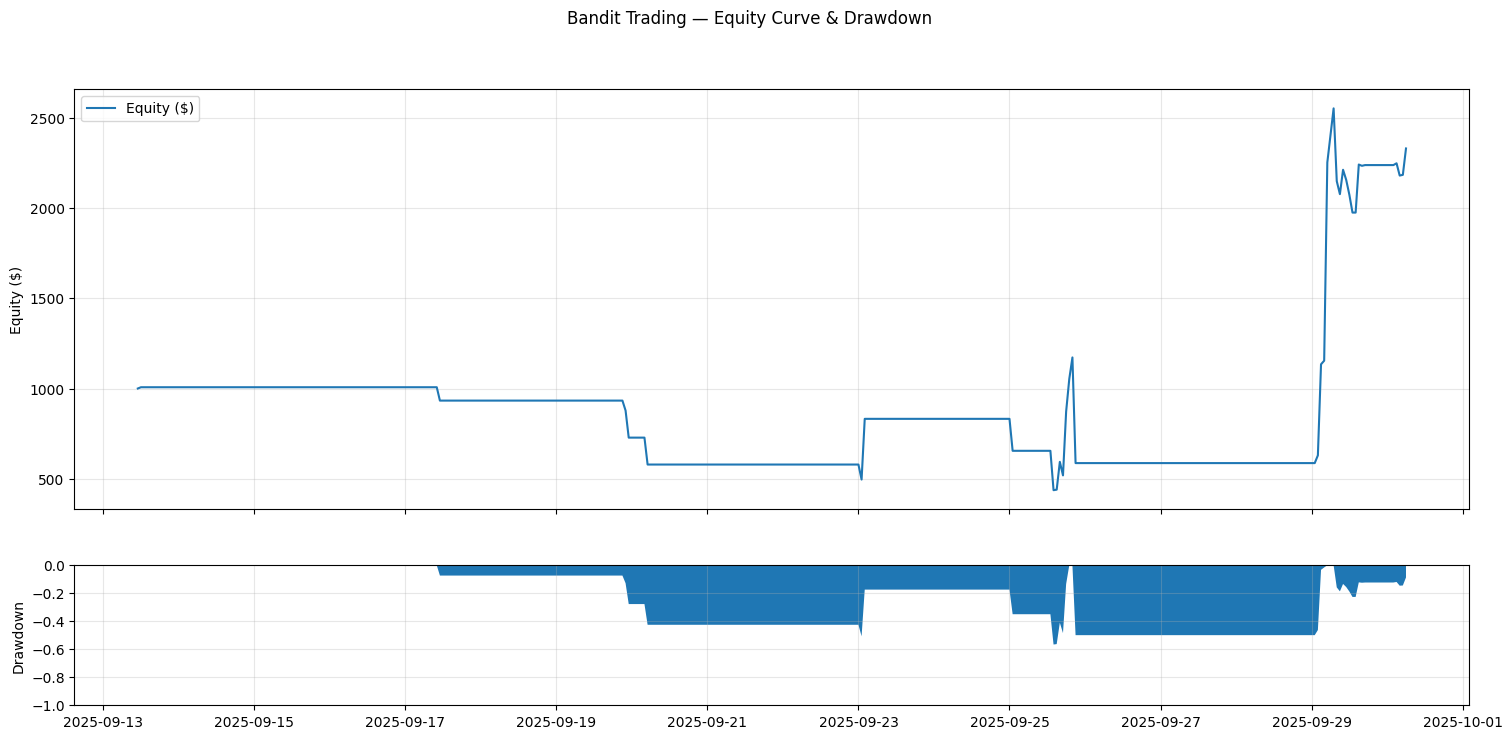

Plot saved → results_demo/sliding_demo/equity_drawdown_backtest_part3.png

========== PERFORMANCE SUMMARY ==========
Initial Equity : $1,000.00
Final Equity   : $2,329.00
Total PnL      : $1,329.00
ROI            : 132.90%
Max Drawdown   : -56.60%


In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# =========================================================
# 1) LOAD DATA
# =========================================================
df = pd.read_csv(out_path)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

price_df = ohlcv[["timestamp", "close"]].copy()
price_df["timestamp"] = pd.to_datetime(price_df["timestamp"])

df = df.merge(price_df, on="timestamp", how="left")

# =========================================================
# 2) MAP ACTION → POSITION
# =========================================================
ACTION_TO_POS = {
    "FLAT": 0,
    "LONG": 1,
    "SHORT": -1,
}
df["pos"] = df["action"].map(ACTION_TO_POS).fillna(0).astype(int)

# =========================================================
# 3) SIMULATE EQUITY (MARK-TO-MARKET)
# =========================================================
INIT_EQUITY = 1000.0

equity = INIT_EQUITY
equity_curve = [equity]
pnls = [0.0]

for i in range(1, len(df)):
    price_prev = df.loc[i - 1, "close"]
    price_now = df.loc[i, "close"]
    pos_prev = df.loc[i - 1, "pos"]

    pnl = pos_prev * (price_now - price_prev)
    equity += pnl

    pnls.append(pnl)
    equity_curve.append(equity)

df["pnl"] = pnls
df["equity"] = equity_curve

# =========================================================
# 4) DRAWDOWN
# =========================================================
df["equity_peak"] = df["equity"].cummax()
df["drawdown"] = (df["equity"] - df["equity_peak"]) / df["equity_peak"]

max_dd = df["drawdown"].min()

# =========================================================
# 5) PLOT — EQUITY & DRAWDOWN
# =========================================================
out_dir = "results_demo/sliding_demo"
os.makedirs(out_dir, exist_ok=True)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(18, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# ---- EQUITY ----
ax1.plot(
    df["timestamp"],
    df["equity"],
    label="Equity ($)",
)
ax1.set_ylabel("Equity ($)")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

# ---- DRAWDOWN ----
ax2.fill_between(
    df["timestamp"],
    df["drawdown"],
    0,
)
ax2.set_ylabel("Drawdown")
ax2.set_ylim(-1.0, 0.0)
ax2.grid(alpha=0.3)

plt.suptitle("Bandit Trading — Equity Curve & Drawdown")

# ---- SAVE FIG ----
run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
fig_path = f"{out_dir}/equity_drawdown_backtest_part3.png"

plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Plot saved → {fig_path}")

# =========================================================
# 6) METRICS
# =========================================================
final_equity = df["equity"].iloc[-1]
total_pnl = final_equity - INIT_EQUITY
roi_pct = total_pnl / INIT_EQUITY * 100

print("\n========== PERFORMANCE SUMMARY ==========")
print(f"Initial Equity : ${INIT_EQUITY:,.2f}")
print(f"Final Equity   : ${final_equity:,.2f}")
print(f"Total PnL      : ${total_pnl:,.2f}")
print(f"ROI            : {roi_pct:.2f}%")
print(f"Max Drawdown   : {max_dd * 100:.2f}%")
print("=========================================")
